# Triton Refill: UCSD Water Station Finder

**Main goal: Help a student find a nearby mapped water station.**

The notebook follows one simple process:

**Open the station data → clean the data → find nearby stations → save the cleaned file for ArcGIS.**

| Part | Simple meaning |
|---|---|
| Open | Turn the saved station list into a Python table. |
| Clean | Fix simple data problems such as extra spaces and missing descriptions. |
| Find | Measure how far each mapped station is from a starting point and put the closest ones first. |
| Check | Make sure the search is behaving the way it should. |
| Save | Create the CSV file used in ArcGIS Online. |

The notebook handles the **data and distance example**. ArcGIS Experience Builder handles the **live student location, map, nearby search, directions, and reporting tools**.

The notebook does not track a student's phone location.

The station data is saved inside the notebook, so a separate CSV does not need to be uploaded before running it.


## 1. Open the station list

### Load the tools

**What this block does:** It brings in the Python tools needed for the project.

- `geopy` gives Python a tool for measuring distance between two map points.
- `pandas` works with tables, similar to a spreadsheet.
- `StringIO` lets Python read the station data that is saved inside the notebook.
- `geodesic` is the distance tool used later.

The first line installs GeoPy. The next lines load the tools.

**Bigger picture:** No station data is changed here. This block only gets the tools ready.


In [ ]:
%pip -q install --no-cache-dir geopy==2.4.1

import pandas as pd
from io import StringIO
from geopy.distance import geodesic

### Save the original station list inside the notebook

**What this block does:** It stores the UCSD water-station list inside the notebook.

The large section of text is **data**, not a complicated calculation.

Each row includes information such as:

- station name
- description
- latitude
- longitude
- source group

The name `csv_data` is simply the name given to this saved text.

**Bigger picture:** Keeping the station list inside the notebook means the project can run without asking someone to upload a separate CSV first. [1]


In [ ]:
# @title Saved water-station list
# This text keeps the data inside the notebook.
csv_data = """station_name,description,latitude,longitude,source_group
The Zone,,32.880002,-117.236862,Hydration Locations
The Sustainability Resource Center,,32.879943,-117.237124,Hydration Locations
Price Theater,,32.879993,-117.237055,Hydration Locations
Price Center - 2nd Floor,Near PC West hallway entrance,32.879695,-117.236588,Hydration Locations
Price Center - 4th Floor,Next to the elevator (PC East),32.879677,-117.236406,Hydration Locations
Porters Pub,Foyer (Currently closed),32.8770015,-117.239479,Hydration Locations
Geisel 1st Floor,There are 4 hydration stations in Geisel,32.8811281,-117.2377258,Hydration Locations
Hi Thai,,32.87719,-117.240214,Hydration Locations
Peterson Hall,,32.880004,-117.240043,Hydration Locations
Galbraith Hall,There are three hydration stations in Galbraith Hall,32.874028,-117.240976,Hydration Locations
CS&E Building,Student Lounge,32.881862,-117.23345,Hydration Locations
Pepper Canyon ,between the bathrooms,32.878209,-117.233954,Hydration Locations
Campus Services Complex Building C,,32.882948,-117.229625,Hydration Locations
Biology Field Station,,32.885561,-117.230161,Hydration Locations
EBU-II,There are hydration stations on every floor,32.881155,-117.233284,Hydration Locations
Recreation Gym,,32.876758,-117.241185,Hydration Locations
Main Gym,,32.877001,-117.241169,Hydration Locations
Dance Studio Facility,,32.872811,-117.238991,Hydration Locations
Medical Teaching Facility,There are two hydration stations here,32.875668,-117.235386,Hydration Locations
HSS,,32.878371,-117.241679,Hydration Locations
Price Center - 3rd Floor,By the restrooms,32.8797696,-117.2357136,Hydration Locations
AP&M 1st Floor Lobby,,32.8792673,-117.2409801,Hydration Locations
AP&M 2nd Floor Lobby,,32.8792673,-117.2409801,Hydration Locations
RIMAC 1,There are 3 hydration stations in RIMAC,32.8852206,-117.2403967,Hydration Locations
RIMAC 2,There are 3 hydration stations in RIMAC,32.8852713,-117.2396484,Hydration Locations
RIMAC 3,There are 3 hydration stations in RIMAC,32.885381,-117.239324,Hydration Locations
Biomed Library,1st Floor Lobby,32.8755347,-117.2366631,Hydration Locations
Canyonview Pool,Hydration station located by locker rooms,32.8807225,-117.2316957,Hydration Locations
Geisel 6th Floor,There are 4 hydration stations in Geisel,32.8811088,-117.2375804,Hydration Locations
Geisel 2nd Floor,There are 4 hydration stations in Geisel,32.8811392,-117.2374047,Hydration Locations
Geisel 8th Floor,There are 4 hydration stations in Geisel,32.881111,-117.2375549,Hydration Locations
Telemed 1st Floor,There are 2 hydration stations in Telemed,32.8752712,-117.2346246,Hydration Locations
Telemed 3rd Floor,There are 2 hydration stations in Telemed,32.8753252,-117.2347319,Hydration Locations
Price Center-1st Floor,Next to Burger King,32.879988,-117.235832,Hydration Locations
Warren Commuter Lounge,,32.8814365,-117.2338817,Hydration Locations
Center Hall,1st Floor - Near the Restrooms,32.87815,-117.236824,Hydration Locations
Student Services Center,1st Floor - Near the stair case and restroom,32.8787087,-117.2356385,Hydration Locations
SIO Administration Building,,32.8649974,-117.254221,Hydration Locations
Deep Sea Drilling West ,,32.86754,-117.251647,Hydration Locations
Eckart Building ,Second Floor ,32.867141,-117.252537,Hydration Locations
Student Activity Center,,32.882403,-117.233182,HDH Hydration Locations
Dogg House,,32.8778572,-117.2332594,HDH Hydration Locations
Warren Residential Life Office,,32.8840216,-117.2333439,HDH Hydration Locations
The Village Residential Life Office,Outside the Lodge,32.8781,-117.230301,HDH Hydration Locations
ERC Great Hall,downstairs between the bathrooms,32.883966,-117.2419363,HDH Hydration Locations
Marshall's Residential Life Office,,32.8831773,-117.2428181,HDH Hydration Locations
Fireside Lounge,,32.8821776,-117.2387713,HDH Hydration Locations
ERC Laundry South,,32.884637,-117.243122,HDH Hydration Locations
Goldberg Hall Laundry Room,Laundry Room ,32.8830966,-117.2338361,HDH Hydration Locations
Argo Hall,,32.8744512,-117.2415447,HDH Hydration Locations
Muir Across from Roots,between the bathrooms,32.8790153,-117.2425509,HDH Hydration Locations
Muir - Roots,,32.8789866,-117.242615,HDH Hydration Locations
Pines,,32.8790009,-117.2424476,HDH Hydration Locations
Goody's Market,,32.882921,-117.240461,HDH Hydration Locations
Blake Hall,,32.875037,-117.241523,HDH Hydration Locations
OceanView Terrace Restaurant,,32.883182,-117.242714,HDH Hydration Locations
Cafe Ventanas,,32.88611,-117.242661,HDH Hydration Locations
Canyon Vista,Inside next to the television and outside next to the main entrance.,32.8839864,-117.2330922,HDH Hydration Locations
Foodworx,,32.878812,-117.23043,HDH Hydration Locations
Seventh College East,The hydration center is at the outside laundry room aka The Soap Bar,32.8882166,-117.2418723,HDH Hydration Locations
Tamarack Apartments,Between bathrooms behind John's Market,32.8782233,-117.2423279,HDH Hydration Locations
Black Hall Laundry Room,Laundry Room ,32.8821235,-117.232672,HDH Hydration Locations
The Village Apartments Laundry Room,Building 300,32.8788213,-117.229405,HDH Hydration Locations
Seventh College Tower West ,Hydration station located in the 15th floor conference room,32.8886127,-117.2422528,HDH Hydration Locations
Matthews Building B,Laundry Room,32.8786974,-117.2308002,HDH Hydration Locations
Seventh College West Building 3,Laundry Room,32.8874753,-117.2427759,HDH Hydration Locations
ERC East Upper Laundry Room,by Kathmandu House,32.8852815,-117.2418841,HDH Hydration Locations
ERC POP Offices,Between bathrooms upstairs of Cafe V,32.8859831,-117.2425184,HDH Hydration Locations
Marshall Uppers Laundry Room,Building J Near hammock lounge,32.8830696,-117.2415823,HDH Hydration Locations
P Building Res Halls,Laundry Room,32.8835268,-117.2429314,HDH Hydration Locations
V Building Res Hall,Laundry room,32.8830223,-117.2431353,HDH Hydration Locations
Keeling Apartment Building 2,Ground floor facing south basketball courts,32.8737258,-117.2432493,HDH Hydration Locations
Revelle - Rogers Market,Hallway by Amazon lockers,32.8745143,-117.2423279,HDH Hydration Locations
Rita Atkinson Residences,4th floor gym,32.8727549,-117.2350645,HDH Hydration Locations
Q Building Res Hall,Laundry room,32.8835516,-117.243138,HDH Hydration Locations
Mesa Nueva,2 by the leasing office,32.8756316,-117.2228229,HDH Hydration Locations
Mesa Nueva - Fitness Center,,32.8750003,-117.2235953,HDH Hydration Locations
Mesa Apartments - Bldg 9156,Laundry Building. In the nook across from the restrooms.,32.8721506,-117.2221383,HDH Hydration Locations
Seventh College West Building 2,Downstairs by the bathroom,32.8880586,-117.2424969,HDH Hydration Locations
OMS Leasing Office/Lounge,"Outside, on the first floor",32.873865,-117.2257905,HDH Hydration Locations
Nuevo West,1 near Fitness Center. 1 near Game Room restrooms.,32.8745228,-117.2248646,HDH Hydration Locations
Nuevo East,2 at Exchange Building. ,32.8746414,-117.2186881,HDH Hydration Locations
Coast,1 in Laundry Room,32.8701292,-117.2469013,HDH Hydration Locations
Nuevo East,1 at the Fitness Center,32.8750448,-117.219354,HDH Hydration Locations
"""

### Turn the saved text into a table

**What this block does:** It turns the saved station text into a table that Python can work with.

- `raw` = the original table.
- `stations` = a copy that will be cleaned.
- `head()` = show the first five rows.

The original table is kept so the cleaned version can be compared with the starting data.

**Bigger picture:** This is the point where the saved text becomes usable data.


In [ ]:
raw = pd.read_csv(StringIO(csv_data))
stations = raw.copy()

stations.head()

,station_name,description,latitude,longitude,source_group
0,The Zone,NaN,32.880002,-117.236862,Hydration Locations
1,The Sustainability Resource Center,NaN,32.879943,-117.237124,Hydration Locations
2,Price Theater,NaN,32.879993,-117.237055,Hydration Locations
3,Price Center - 2nd Floor,Near PC West hallway entrance,32.879695,-117.236588,Hydration Locations
4,Price Center - 4th Floor,Next to the elevator (PC East),32.879677,-117.236406,Hydration Locations


## 2. Clean and check the data

### Count the rows and find missing information

**What this block does:** It checks how much data is in the table and how much information is missing.

- `len(raw)` counts the rows.
- `isna()` finds empty cells.
- `sum()` counts the empty cells.

The number of missing descriptions is saved before any cleaning happens.

**Bigger picture:** Before changing data, it is useful to understand what problems are already there.


In [ ]:
original_count = len(raw)
missing_descriptions = raw["description"].isna().sum()

print("Mapped entries:", original_count)
print("Missing descriptions:", missing_descriptions)
raw.isna().sum()

Mapped entries: 84
Missing descriptions: 31


,0
station_name,0
description,31
latitude,0
longitude,0
source_group,0


### Clean the text and label missing descriptions

**What this block does:** It fixes a few simple text problems.

- `str.strip()` removes extra spaces from the beginning or end of text.
- Empty descriptions are treated as missing.
- `fillna()` changes missing descriptions to **"No details provided."**

No station description is invented.

**Bigger picture:** The goal is to make the table cleaner and easier to show in the app.


In [ ]:
stations["station_name"] = stations["station_name"].str.strip()
stations["description"] = stations["description"].str.strip()
stations["source_group"] = stations["source_group"].str.strip()

# Treat a description containing only spaces as missing too.
stations["description"] = stations["description"].replace("", pd.NA)
stations["description"] = stations["description"].fillna("No details provided")

### Remove only exact duplicate rows

**What this block does:** It checks whether the exact same row appears more than once.

- `duplicated()` counts exact repeats.
- `drop_duplicates()` removes exact repeated rows.
- `reset_index()` gives the remaining rows clean row numbers again.

Two stations are **not** removed just because they have the same coordinates. For example, two different floors of the same building can use the same map point.

**Bigger picture:** Remove accidental copies without deleting real station records.


In [ ]:
repeated_rows = stations.duplicated().sum()
print("Exact repeated rows:", repeated_rows)

stations = stations.drop_duplicates()
stations = stations.reset_index(drop=True)

print("Entries kept:", len(stations))

Exact repeated rows: 0
Entries kept: 84


### Check the latitude and longitude

**What this block does:** It makes sure the map coordinates look like valid numbers.

Latitude and longitude are the numbers ArcGIS uses to place a station on the map.

The code:

1. changes the coordinate columns into numbers,
2. checks that latitude is between -90 and 90,
3. checks that longitude is between -180 and 180,
4. stops the notebook if an important check fails.

`assert` can be thought of as a **stop sign**. If something important is wrong, the notebook stops instead of continuing with bad data.

**Bigger picture:** This catches basic coordinate problems before the data is sent to ArcGIS.


In [ ]:
# Change coordinate cells to numbers. Invalid text becomes a missing value.
stations["latitude"] = pd.to_numeric(stations["latitude"], errors="coerce")
stations["longitude"] = pd.to_numeric(stations["longitude"], errors="coerce")

latitude_ok = stations["latitude"].between(-90, 90).all()
longitude_ok = stations["longitude"].between(-180, 180).all()

assert len(stations) > 0, "The station table is empty."
assert stations["station_name"].notna().all(), "A station name is missing."
assert (stations["station_name"] != "").all(), "A station name is blank."
assert latitude_ok and longitude_ok, "Check missing or invalid coordinates."

print("Names and coordinate numbers passed the basic checks.")

Names and coordinate numbers passed the basic checks.


### Add source and status information

**What this block does:** It adds information that should stay with each station.

Every station gets:

- the source map link,
- a warning that current condition and access hours have not been checked.

The code also looks for the word **"closed"** in a description. If it finds one, that station gets a stronger warning.

**Bigger picture:** The app should be useful without pretending the old source data is live or fully verified.


In [ ]:
source_url = "https://www.google.com/maps/d/viewer?mid=18OFCg3GFp6wl5mCwioSvU9fdGAA&usp=sharing"
stations["source_url"] = source_url
stations["status_note"] = "Current condition and access hours have not been checked."

# Find an old closure note, without removing the record.
closure_note = stations["description"].str.contains("closed", case=False, na=False)
stations.loc[closure_note, "status_note"] = (
    "Source says closed (no date). Current condition and access are unverified."
)

stations.loc[closure_note, ["station_name", "description", "status_note"]]

,station_name,description,status_note
5,Porters Pub,Foyer (Currently closed),Source says closed (no date). Current conditio...


### Make a simple data-quality summary

**What this block does:** It puts the cleaning results into one small table.

The table shows things such as:

- how many original entries there were,
- how many descriptions were missing,
- the percentage of missing descriptions,
- how many exact duplicates were found,
- how many cleaned entries remain.

The percentage is:

**missing descriptions ÷ total entries × 100**

**Bigger picture:** This gives a quick summary of what was found during data cleaning.


In [ ]:
missing_percent = missing_descriptions / original_count * 100

quality = pd.DataFrame({
    "Check": ["Original entries", "Missing descriptions", "Missing descriptions (%)",
              "Exact repeats removed", "Cleaned entries", "Undated closure notes"],
    "Result": [original_count, missing_descriptions, round(missing_percent, 1),
               repeated_rows, len(stations), int(closure_note.sum())]
})
quality

,Check,Result
0,Original entries,84.0
1,Missing descriptions,31.0
2,Missing descriptions (%),36.9
3,Exact repeats removed,0.0
4,Cleaned entries,84.0
5,Undated closure notes,1.0


## 3. Find nearby stations

### Create one reusable station-search function

**What this block does:** It creates a reusable set of steps called `find_stations`.

A **function** is just code that is given a name so the same steps can be used again.

This function works like this:

**Starting latitude + starting longitude → measure distance to every station → sort the stations from closest to farthest.**

Inside the function:

1. the starting coordinates are checked,
2. the code goes through the station table one row at a time,
3. `geodesic()` measures the direct map distance to each station,
4. those distances are added to the results,
5. `sort_values()` puts the smallest distances first.

**Bigger picture:** This is the main idea behind finding the nearest station.

The distance is a direct map distance. It is **not** a walking route and does not know about stairs, doors, floors, or building hours. [2, 3]


In [ ]:
def find_stations(latitude, longitude):
    # Reject location numbers outside the allowed range.
    if not (-90 <= latitude <= 90 and -180 <= longitude <= 180):
        raise ValueError("Enter a valid latitude and longitude.")

    start = (latitude, longitude)
    distances = []

    # Measure from the starting point to one station at a time.
    for row_number, station in stations.iterrows():
        station_location = (station["latitude"], station["longitude"])
        distance_m = geodesic(start, station_location).meters
        distances.append(distance_m)

    # Add distances to a copy, leaving the station table unchanged.
    results = stations.copy()
    results["distance_m"] = distances
    results = results.sort_values(["distance_m", "station_name"])
    return results.reset_index(drop=True)

### Test the search with one example location

**What this block does:** It gives the search a sample starting point.

The example uses an approximate point for the UC San Diego Central Campus trolley station. [4]

The settings are:

- search up to **500 meters** away,
- show up to **3 nearby results**.

Then `find_stations()` is run and the code keeps only stations inside the 500-meter search distance.

**Bigger picture:** This is a simple example of what the live ArcGIS app will do with a student's location.


In [ ]:
start_latitude = 32.878353
start_longitude = -117.231842
search_radius_m = 500
number_to_show = 3

assert search_radius_m > 0, "The search distance must be positive."
assert number_to_show > 0, "Show at least one result."

ranked = find_stations(start_latitude, start_longitude)
nearby = ranked[ranked["distance_m"] <= search_radius_m]
print("Mapped entries inside the search distance:", len(nearby))

Mapped entries inside the search distance: 21


### Show the closest few stations

**What this block does:** It takes the nearby results and displays the first three.

Because the search already put the closest stations first:

- `head(3)` means **take the first three closest results**.
- The distance is rounded to make it easier to read.
- The station name, distance, description, and status warning are shown.

If no station is inside the search distance, the code shows a message instead.

**Bigger picture:** This creates the kind of information a student needs: nearby options and useful station details.


In [ ]:
top_choices = nearby.head(number_to_show).copy()
top_choices["distance_m"] = top_choices["distance_m"].round(0)

if top_choices.empty:
    print("No mapped stations in this search area. Increase the distance or choose another point.")
else:
    display(top_choices[["station_name", "distance_m", "description", "status_note"]])

,station_name,distance_m,description,status_note
0,Matthews Building B,105.0,Laundry Room,Current condition and access hours have not be...
1,Foodworx,142.0,No details provided,Current condition and access hours have not be...
2,Dogg House,144.0,No details provided,Current condition and access hours have not be...


### Make a simple distance chart

**What this block does:** It makes a bar chart of the example results.

Each bar represents one nearby mapped station.

- shorter bar = closer map distance
- longer bar = farther map distance

`matplotlib` is the tool that draws the chart.

**Bigger picture:** The chart is only another way to look at the example search results. It does not show a walking route.


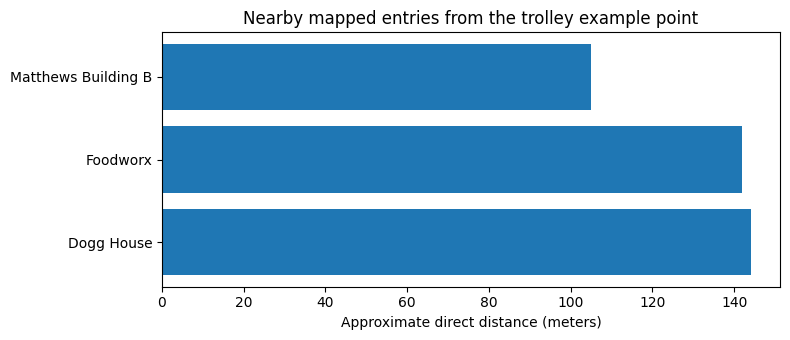

In [ ]:
import matplotlib.pyplot as plt

if not top_choices.empty:
    plt.figure(figsize=(8, 3.5))
    plt.barh(top_choices["station_name"], top_choices["distance_m"])
    plt.gca().invert_yaxis()
    plt.xlabel("Approximate direct distance (meters)")
    plt.title("Nearby mapped entries from the trolley example point")
    plt.tight_layout()
    plt.savefig("triton_refill_example.png", dpi=160)
    plt.show()

## 4. Check that the search works correctly

### Run a few automatic checks

**What this block does:** It checks whether the search follows the rules we expect.

The code checks that:

1. the stations are ordered from closest to farthest,
2. every result in `nearby` is inside the chosen search distance,
3. a very tiny one-meter search returns no result for this example.

If one of these checks fails, `assert` stops the notebook.

**Bigger picture:** These are simple software tests used to catch mistakes in the search logic.


In [ ]:
check_results = []

# The distances should run from smallest to largest.
distance_list = ranked["distance_m"].tolist()
assert distance_list == sorted(distance_list)
check_results.append(["Closest entries come first", "Passed"])

# Every nearby result must be inside the chosen search distance.
assert (nearby["distance_m"] <= search_radius_m).all()
check_results.append(["Nearby results stay inside the search distance", "Passed"])

# This very small search should return no records.
one_meter_results = ranked[ranked["distance_m"] <= 1]
assert one_meter_results.empty
check_results.append(["A one-meter example search returns no results", "Passed"])

### Run three more search checks

**What this block does:** It tests the search with a few situations where the answer is easy to predict.

The code checks that:

1. starting exactly on a saved station gives a distance of about zero,
2. a made-up point far away from UCSD has no nearby stations,
3. both AP&M floor records are still in the cleaned data.

The final results are put into a small `checks` table.

**Bigger picture:** These checks make sure the cleaning and search did not accidentally break important station records.


In [ ]:
# Start at the exact coordinates of one saved station.
known_station = stations.iloc[0]
at_station = find_stations(known_station["latitude"], known_station["longitude"])
assert at_station.iloc[0]["distance_m"] < 0.01
check_results.append(["A stored station point gives zero distance", "Passed"])

# Search far away from the campus data.
faraway = find_stations(0, 0)
assert faraway[faraway["distance_m"] <= 500].empty
check_results.append(["A faraway test point returns no nearby entries", "Passed"])

# Keep the separate floors even though their coordinates match.
apm_records = stations[stations["station_name"].isin(
    ["AP&M 1st Floor Lobby", "AP&M 2nd Floor Lobby"]
)]
assert len(apm_records) == 2
check_results.append(["Both AP&M floor records are kept", "Passed"])

checks = pd.DataFrame(check_results, columns=["Check", "Result"])
checks

,Check,Result
0,Closest entries come first,Passed
1,Nearby results stay inside the search distance,Passed
2,A one-meter example search returns no results,Passed
3,A stored station point gives zero distance,Passed
4,A faraway test point returns no nearby entries,Passed
5,Both AP&M floor records are kept,Passed


## 5. Save the files

### Save the results as CSV files

**What this block does:** It saves the useful tables as files.

`to_csv()` means **save this table as a CSV file**.

The main file is:

**`triton_refill_stations_rebuild.csv`**

That is the cleaned station file used for the ArcGIS Online layer.

The block also saves:

- the data-quality checks,
- the search checks,
- the example search results.

`index=False` keeps Python's row numbers out of the CSV files.

**Bigger picture:** Python prepares the data. These saved files are what can be used outside the notebook.


In [ ]:
stations.to_csv("triton_refill_stations_rebuild.csv", index=False)
quality.to_csv("triton_refill_data_checks.csv", index=False)
checks.to_csv("triton_refill_search_checks.csv", index=False)

example_export = top_choices.copy()
example_export["example_start_latitude"] = start_latitude
example_export["example_start_longitude"] = start_longitude
example_export["example_search_radius_m"] = search_radius_m
example_export["example_note"] = "Saved demonstration point; not a live location or walking route."
example_export.to_csv("triton_refill_example_results.csv", index=False)

print("Saved the station list, data checks, search checks and example results.")

Saved the station list, data checks, search checks and example results.


### Create an empty file for future campus testing

**What this block does:** It creates a blank table for real-world testing later.

The columns can record:

- where a test started,
- which station was selected,
- whether the station was found,
- whether it worked during the visit,
- how long it took to reach.

No test results are added here.

**Bigger picture:** This keeps real campus observations separate from the example calculations in the notebook.


In [ ]:
field_checks = pd.DataFrame(columns=[
    "test_number", "visit_date", "starting_place", "station_selected",
    "station_found", "usable_at_visit", "minutes_to_station", "notes"
])
field_checks.to_csv("triton_refill_field_checks_blank.csv", index=False)

print("Created an empty visit log. No field tests have been recorded.")

Created an empty visit log. No field tests have been recorded.


### Download the ArcGIS CSV from Colab

**What this block does:** It downloads the cleaned station CSV from Colab to the computer.

The file is:

**`triton_refill_stations_rebuild.csv`**

`files.download(...)` means **download this file through the browser**.

**Bigger picture:** This is the file that can be uploaded to ArcGIS Online to create the station layer. This block only downloads the file; it does not change ArcGIS.


In [ ]:
# Bring in Colab’s file download tool.
from google.colab import files

# Download the cleaned station CSV to the computer.
files.download("triton_refill_stations_rebuild.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. How this connects to the ArcGIS app

The notebook and the ArcGIS app have different jobs.

**Notebook:** prepare and check the station data.

**ArcGIS Experience Builder:** use the student's current location, show nearby stations, give directions, and display station information.

The basic app idea is:

**Student location → nearby stations → station details → directions or report a problem**

| App part | Simple purpose |
|---|---|
| Map | Show the UCSD water-station locations. |
| Locate | Show the student's current location after permission is given. |
| Near Me | Find stations near the selected/current location. |
| 500-meter search | Limit the search to nearby mapped stations. |
| Station details | Show the name, description, and status note. |
| Manual point | Let someone search without sharing their location. |
| Directions | Help the student travel from the current location to a selected station. |
| Report Station | Let students report problems with a station. |

The ArcGIS app does **not** run this Python notebook. It uses the cleaned station layer created from the CSV.

Small distance differences between Python and ArcGIS are possible because they are separate tools.

**Bigger picture:** Python prepares the data; ArcGIS turns that data into the student-facing app.


## Summary

**Triton Refill has one main purpose: help UCSD students find nearby mapped water stations.**

The notebook does four main things:

1. opens the station data,
2. cleans and checks it,
3. tests a simple nearest-station search,
4. saves the cleaned CSV for ArcGIS Online.

The source contains **84 mapped entries**. **31 descriptions (36.9%)** were missing, so those blanks were labeled **"No details provided"** instead of guessing information.

The example search shows how a starting location can be compared with the station list so the closest mapped options appear first.

The software checks make sure the search behaves correctly. They do not prove that a station is currently working or accessible.

The live student experience is built in ArcGIS Experience Builder, not in this notebook.

**Main project theme: Find water nearby.**


## Sources

**[1] Station data.** [UC San Diego Hydration Locations](https://www.google.com/maps/d/viewer?mid=18OFCg3GFp6wl5mCwioSvU9fdGAA&usp=sharing), linked by [UCSD HDH Sustainability](https://hdhsustainability.ucsd.edu/). The supplied KMZ was converted to a CSV earlier in this project. That saved data is included here. The source update date is unknown; current conditions and access have not been verified.

**[2] Table tools.** pandas documentation: [reading CSV files](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html), [sorting values](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html), [reading one row at a time](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html), and [saving CSV files](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html).

**[3] Distance tool.** [GeoPy: calculating distance](https://geopy.readthedocs.io/en/stable/#calculating-distance). This version uses `geodesic` with latitude first and longitude second. It returns a direct distance in meters, not a walking route. Earlier notebooks used a different direct-distance formula, so very small numerical differences are expected.

**[4] Example starting point.** [UCSD Stuart Collection: visit via trolley](https://stuartcollection.ucsd.edu/map/visit-via-trolley.html). Coordinates **32.878353, -117.231842** were retained from the named Central Campus station waypoint in the page's embedded map, as recorded in the earlier project. This is an approximate reference, not a verified ground-level entrance or a newly measured point.

**[5] Live map.** [Esri: Experience Builder Map widget](https://doc.arcgis.com/en/experience-builder/latest/configure-widgets/map-widget.htm). Describes Locate, Watch location and the Location change action.

**[6] Nearby results.** [Esri: Experience Builder Near Me widget](https://doc.arcgis.com/en/experience-builder/latest/configure-widgets/near-me-widget.htm). Describes search distance, Proximity, distance sorting, manual point input and optional input saving.

**[7] Location permission and limits.** [W3C: Geolocation](https://www.w3.org/TR/geolocation/). Location access requires permission and a secure page; updates depend on the browser and whether the page is active and visible.

**[8] Publishing the data.** [Esri: publish hosted feature layers](https://doc.arcgis.com/en/arcgis-online/manage-data/publish-features.htm). The station CSV can be published using its latitude and longitude fields, with the required account permissions.

**[9] Sharing the notebook.** [Google Colab FAQ](https://research.google.com/colaboratory/faq.html). The notebook can be uploaded to Colab and shared. Its data is embedded, but exported files in a temporary runtime must be saved separately.

**[10] Downloading from Colab.** [Google Colab file tools](https://github.com/googlecolab/colabtools/blob/main/google/colab/files.py). `files.download()` sends an existing Colab file to the browser. This is separate from saving a file with `to_csv()`.

**Tools:** Python, pandas, GeoPy and Matplotlib for the notebook; ArcGIS Online and Experience Builder for the planned live-location app. The browser app and campus visits are not completed by running Python.